## **Figure-5**

In [1]:
import pandas as pd
import polars as pl
import sys 
from collections import defaultdict
import os
import re
from functools import reduce

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


---

In [3]:
names = dict(bruker='timsTOF, 2024',
             silico='in-silico',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based')

In [4]:
# Use default mpl color cycle
default_colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

condition_palette = {
    condition['orig']: default_colors[0],
    condition['refined']: default_colors[1],
}


# **Load Data**

### **Identification Rates**

#### **Load Data - DIA-NN**

In [5]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'-(\d+pg)-', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderDiann(diann_dir, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {str(i):defaultdict(dict) for i in condition.values() }

    # Define custom sort order for dilutions
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']

    # Get all dilution directories within diann directory
    dilution_dirs = []
    if os.path.isdir(diann_dir):
        dilution_dirs = [d for d in os.listdir(diann_dir) 
                        if os.path.isdir(os.path.join(diann_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(diann_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            lib_dirs = [d for d in os.listdir(replicate_path) 
                       if os.path.isdir(os.path.join(replicate_path, d))
                       and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, "report.tsv")

                lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists
                if os.path.exists(report_path):
                    try:
                        # Call getPrecursorSetDiann function
                        result = getPrecursorSetDiann(report_path, **kwargs)

                        if lib_dilution == '500pg':
                            # Store both the result and the library name
                            rslts[condition['refined']][replicate] = result

                            print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
                    except Exception as e:
                        print(f"Error processing {report_path}: {str(e)}")
                        raise e
                else:
                    print(f"Missing report.tsv file in {os.path.join(replicate_path, lib_dir)}")
    return rslts


def appendOriginalResultsDiann(diann_dir, rslts, **kwargs):
    # Get all experiment directories within diann directory
    diann_experiment_dirs = []
    if os.path.isdir(diann_dir):
        diann_experiment_dirs = [d for d in os.listdir(diann_dir) 
                               if os.path.isdir(os.path.join(diann_dir, d)) and '_0pg' not in d and "R2024" not in d and '100pg' in d]
    
    # Process each directory
    for dir_name in diann_experiment_dirs:
        # Extract dilution and replicate
        dilution, replicate = extract_info(dir_name)
        
        # Path to report.tsv
        report_path = os.path.join(diann_dir, dir_name, "report.tsv")

        # Check if file exists
        if os.path.exists(report_path):
            try:
                # Call getPrecursorSertDiann function
                result = getPrecursorSetDiann(report_path, **kwargs)
                rslts[condition['orig']][replicate] = result

                print(f"Processed {dir_name} successfully (dilution: {dilution}, replicate: {replicate})")
            except Exception as e:
                print(f"Error processing {dir_name}: {str(e)}")
        else:
            print(f"Skipping {dir_name}: Missing report.tsv file")

diann = {}

diann[names['bruker']] = loadRefinedFolderDiann("../../results/SCP-Bruker-Lib-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-Bruker-Library-Analysis/diann/", diann[names['bruker']])

diann[names['silico']] = loadRefinedFolderDiann("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-PeptDeep-NoMods-Analysis/diann/", diann[names['silico']])

diann[names['diatracer']] = loadRefinedFolderDiann("../../results/SCP-diaTracer-Refined-Analysis/diann/", infer_schema_length=10000)
appendOriginalResultsDiann("../../results/SCP-diaTracer-Analysis/diann/", diann[names['diatracer']], infer_schema_length=10000)

../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-2500pg-rep2_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-1000pg-rep3_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-250pg-rep1_lib/report.tsv
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-500pg-rep3_lib/report.tsv
Processed 100pg rep 2 | lib dilution 500pg | lib directory 2025-06-17-Refine-BrukerLib-500pg-rep3_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_8_S2-C5_1_1717/2025-06-17-Refine-BrukerLib-250

#### **Load Data - OSW**

In [6]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {str(i):defaultdict(dict) for i in condition.values() }

    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            if alt_lib_dir:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                        if os.path.isdir(os.path.join(replicate_path, d))
                        and d.startswith('lib')]
            else:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                           if os.path.isdir(os.path.join(replicate_path, d))
                           and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                if '_500pg' in lib_dir: # only do 500pg
                    # Path to report.tsv
                    report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                    
                    if alt_lib_dir:
                        lib_dilution = extract_lib_info_alt(lib_dir)
                    else:
                        lib_dilution = extract_lib_info(lib_dir)

                    # Check if file exists, if not use pyprophet fallback
                    if not os.path.exists(report_path):
                        report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )

                    rslts[condition['refined']][replicate] = getPrecursorSet_oswpq(report_path)
                    print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
    return rslts

def appendOriginalResultsOSW(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if dilution == '0':
            continue
        report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
        
        # Check if file exists, if not use pyprophet fallback
        if not os.path.exists(report_path):
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
        
        rslts[condition['orig']][replicate] = getPrecursorSet_oswpq(report_path)
        print(f"Processed {dilution_dir} rep {replicate} | lib original")
        
def appendOriginalResultsOSWDiaTracer(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        runName_dirs = [d for d in os.listdir(os.path.join(osw_dir, dilution_dir)) 
                        if os.path.isdir(os.path.join(osw_dir, dilution_dir, d))
                        and re.search(r'pg', d)]
        
        for runName in runName_dirs: 
            dilution, replicate = extract_info(runName)

            report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_folder, runName + ".oswpq")

            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_fallback, runName + ".oswpq/" )

            if not os.path.exists(report_path):
                print(f'ERROR: {dilution_dir} rep {replicate} | lib original not found')
                continue
                
            rslts[condition['orig']][replicate] = getPrecursorSet_oswpq(report_path)
            print(f"Processed {dilution_dir} rep {replicate} | lib original")

osw = {}

osw[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", osw[names['bruker']])

osw[names['diatracer']] = loadRefinedFolderOSW("../../results/SCP-diaTracer-Refined-Analysis/osw/", alt_lib_dir=True)
appendOriginalResultsOSWDiaTracer("../../results/SCP-diaTracer-Analysis/osw", osw[names['diatracer']])

osw[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", osw[names['silico']], pyprophet_folder='pyprophet_SVM')

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713.oswpq/
Processed 100pg rep 4 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718.oswpq/
Processed 100pg rep 9 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100p

#### **Format For Plot**

Here going to create an identification vs reproducibility plot

In [7]:
diann_df = format_ids_vs_reproducibility(diann)
osw_df = format_ids_vs_reproducibility(osw)

---

## **Load Quantification Data**

In [8]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {condition['orig']:defaultdict(dict), condition['refined']:defaultdict(dict)}

    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            if alt_lib_dir:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                        if os.path.isdir(os.path.join(replicate_path, d))
                        and d.startswith('lib')]
            else:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                           if os.path.isdir(os.path.join(replicate_path, d))
                           and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                if not '100pg' in lib_dir: # do not show the MBR level (100pg with 100pg) because not everything has this
                    # Path to report.tsv
                    report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                        
                    if alt_lib_dir:
                            lib_dilution = extract_lib_info_alt(lib_dir)
                    else:
                        lib_dilution = extract_lib_info(lib_dir)
                    if lib_dilution == '500pg':
                        # Check if file exists, if not use pyprophet fallback
                        if not os.path.exists(report_path):
                            report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )
        
                        rslts[condition['refined']][replicate] = getPrecursorDf_oswpq(report_path, suffix=replicate)
                        print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
    return rslts

def appendOriginalResultsOSW(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if dilution == '0':
            continue
        report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
        
        # Check if file exists, if not use pyprophet fallback
        if not os.path.exists(report_path):
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
        
        rslts[condition['orig']][replicate] = getPrecursorDf_oswpq(report_path, suffix=replicate)
        print(f"Processed {dilution_dir} rep {replicate} | lib original")
        
def appendOriginalResultsOSWDiaTracer(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        runName_dirs = [d for d in os.listdir(os.path.join(osw_dir, dilution_dir)) 
                        if os.path.isdir(os.path.join(osw_dir, dilution_dir, d))
                        and re.search(r'pg', d)]
        
        for runName in runName_dirs: 
            dilution, replicate = extract_info(runName)

            report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_folder, runName + ".oswpq")

            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_fallback, runName + ".oswpq/" )

            if not os.path.exists(report_path):
                continue
                
            rslts[condition['orig']][replicate] = getPrecursorDf_oswpq(report_path, suffix=replicate)
            print(f"Processed {dilution_dir} rep {replicate} | lib original")

quant_osw = {}

quant_osw[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", quant_osw[names['bruker']])

quant_osw[names['diatracer']] = loadRefinedFolderOSW("../../results/SCP-diaTracer-Refined-Analysis/osw/", alt_lib_dir=True)
appendOriginalResultsOSWDiaTracer("../../results/SCP-diaTracer-Analysis/osw/", quant_osw[names['diatracer']])


quant_osw[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", quant_osw[names['silico']], pyprophet_folder='pyprophet_SVM')

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_4_S2-A4_1_1713.oswpq/
Processed 100pg rep 4 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718/HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_9_S2-C6_1_1718.oswpq/
Processed 100pg rep 9 | lib dilution 500pg | lib directory HeLa02DDM_500pg_5x3_PyDIA_3_S1-C12_1_1644_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100p

In [9]:
def formatData_forQuant(rslts):
    rslts_reduced = reduce(lambda x, y: pd.merge(x,y, left_index=True, right_index=True, how='inner'), rslts.values())
            
    # compute CV across all
    columns = ['FEATURE_MS2.AREA_INTENSITY' + '_' + i for i in rslts.keys() ] 
    
    rslts_reduced['cv'] = rslts_reduced[columns].std(axis=1) / rslts_reduced[columns].mean(axis=1) * 100 
    
    return rslts_reduced

cvs = defaultdict(dict)
for lib, v in quant_osw.items():
    for cond, vv in v.items():
        print(lib, cond)
        cvs[lib][cond] = formatData_forQuant(vv)
        

cvs_df = []
for lib, v in cvs.items():
    tmp = []
    for cond, vv in v.items():
        vv['Condition'] = cond
        vv['Library'] = lib
        vv['Index'] = np.arange(1, len(vv) + 1)
        tmp.append(vv)
    cvs_df.append(pd.concat(tmp))

cvs_df = pd.concat(cvs_df)
cvs_df = cvs_df.reset_index()

timsTOF, 2024 Initial
timsTOF, 2024 Reference-based
Direct Initial
Direct Reference-based
in-silico Initial
in-silico Reference-based


## **Load Chromatographic Data**

In [10]:
pg_500_chromatograms = pd.read_pickle("pg_500_chromatogram.pkl")
pg_100_chromatograms = pd.read_pickle("pg_100_chromatogram.pkl")

In [11]:
prec = 'YNPENLATLER'
chg = 2

In [12]:
pg_100_full_feature_refined = pd.read_parquet("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630/HeLa02DDM_500pg_5x3_PyDIA_1_S1-C10_1_1642_lib/pyprophet_LDA/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630.oswpq/", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])
pg_100_full_feature_refined = pg_100_full_feature_refined[(pg_100_full_feature_refined['MODIFIED_SEQUENCE'] == prec) & 
                                        (pg_100_full_feature_refined['PRECURSOR_CHARGE'] == chg) &
                                        (pg_100_full_feature_refined['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

pg_100_full_feature_orig = pd.read_parquet("../../results/SCP-PeptDeep-NoMods-Analysis/osw/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630/pyprophet_SVM/HeLa02DDM_100pg_5x3_PyDIA_1_S1-C4_1_1630.oswpq/", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])
pg_100_full_feature_orig = pg_100_full_feature_orig[(pg_100_full_feature_orig['MODIFIED_SEQUENCE'] == prec) & 
                                        (pg_100_full_feature_orig['PRECURSOR_CHARGE'] == chg) &
                                        (pg_100_full_feature_orig['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

pg_500_full_feature = pd.read_parquet("../../results/SCP-PeptDeep-NoMods-Analysis/osw/HeLa02DDM_500pg_5x3_PyDIA_1_S1-C10_1_1642/pyprophet_SVM/HeLa02DDM_500pg_5x3_PyDIA_1_S1-C10_1_1642.oswpq", columns=['MODIFIED_SEQUENCE', 'DELTA_RT', 'EXP_RT', 'PRECURSOR_CHARGE', 'SCORE_MS2_PEAK_GROUP_RANK', 'SCORE_MS2_PEP', 'LEFT_WIDTH', 'RIGHT_WIDTH'])

pg_500_full_feature = pg_500_full_feature[(pg_500_full_feature['MODIFIED_SEQUENCE'] == prec) & 
                                        (pg_500_full_feature['PRECURSOR_CHARGE'] == chg) &
                                        (pg_500_full_feature['SCORE_MS2_PEAK_GROUP_RANK'] == 1)].iloc[0]

---

In [13]:
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def createChromatograms(ax1, 
                        ax2, 
                        xlim=(940, 1040), 
                        ylim=(0, 700), 
                        line_width=1.0,
                        vspan_color='yellow', 
                        vspan_alpha=0.3, 
                        vline_color = 'tab:blue',
                        vline_color2 = 'tab:orange',
                        text_y=550,
                        font_size_small=7,
                        font_size_medium=8,
                        font_size_large=10,
                        labelpad=3):
    
    # --- Data Retrieval (Assuming these variables are available in the scope) ---
    target_sample_pep_orig_lib = pg_100_full_feature_orig['SCORE_MS2_PEP']
    target_sample_pep_refined_lib = pg_100_full_feature_refined['SCORE_MS2_PEP']
    reference_sample_pep_orig_lib = pg_500_full_feature['SCORE_MS2_PEP']
    
    # --- Plot Reference Sample (ax1) ---
    pg_500_chromatograms.plot(
        backend='ms_matplotlib',
        x='rt',
        y='intensity',
        by='annotation',
        kind='chromatogram',
        title='Reference Sample (500 pg)',
        xlabel='',
        canvas=ax1,
        line_width=line_width,
        show_plot=False,
        title_font_size=font_size_large,
        xaxis_label_font_size=font_size_large,
        yaxis_label_font_size=font_size_large, 
        xaxis_labelpad=labelpad,
        yaxis_labelpad=labelpad,
        xaxis_tick_font_size=font_size_medium,
        yaxis_tick_font_size=font_size_medium,
        grid=False,
        color=iter(default_colors),
        legend_config=dict(show=True)
    )
    ax1.set_xlim(*xlim)
    ax1.set_ylim(*ylim)
    ax1.axvspan(pg_500_full_feature['LEFT_WIDTH'], pg_500_full_feature['RIGHT_WIDTH'], color=vspan_color, alpha=vspan_alpha)

    ax1.axvline(pg_500_full_feature['EXP_RT'] - pg_500_full_feature['DELTA_RT'], color=vline_color, lw=2, ls='--') # Reduced lw from 3 to 2
    ax1.text(
        pg_500_full_feature['EXP_RT'] - pg_500_full_feature['DELTA_RT'] - 5,
        text_y/2,
        'Initial RT',
        ha='right',
        fontsize=font_size_medium,
        color='white',
        bbox=dict(
            facecolor=vline_color,
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    # --- Plot Target Sample (ax2) ---
    pg_100_chromatograms.plot(
        backend='ms_matplotlib',
        x='rt',
        y='intensity',
        by='annotation',
        kind='chromatogram',
        xlabel='Retention Time (RT)',
        title='Target Sample (100 pg)',
        canvas=ax2,
        line_width=line_width,
        show_plot=False,
        title_font_size=font_size_large,
        xaxis_label_font_size=font_size_large,
        yaxis_label_font_size=font_size_large, 
        xaxis_labelpad=labelpad,
        yaxis_labelpad=labelpad,
        xaxis_tick_font_size=font_size_medium,
        yaxis_tick_font_size=font_size_medium,
        color=iter(default_colors),
        grid=False,
        legend_config=dict(show=False)
    )
    ax2.set_xlim(*xlim)
    ax2.set_ylim(*ylim)
    ax2.axvspan(pg_100_full_feature_refined['LEFT_WIDTH'], pg_100_full_feature_refined['RIGHT_WIDTH'], color=vspan_color, alpha=vspan_alpha)
    ax2.axvline(pg_100_full_feature_refined['EXP_RT'] - pg_100_full_feature_refined['DELTA_RT'], color=vline_color2, lw=2, ls='--') # Reduced lw from 3 to 2

    ax2.text(
        pg_100_full_feature_refined['EXP_RT'] + pg_100_full_feature_refined['DELTA_RT'] + 12,
        text_y/2,
        'Reconstructed\nRT',
        ha='left',
        fontsize=font_size_medium,
        color='black',
        bbox=dict(
            facecolor=vline_color2,
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    ax2.axvline(pg_100_full_feature_refined['EXP_RT'] - pg_100_full_feature_orig['DELTA_RT'], color=vline_color, lw=2, ls='--') # Reduced lw from 3 to 2
    ax2.text(
        pg_100_full_feature_refined['EXP_RT'] + pg_100_full_feature_orig['DELTA_RT'] + 15,
        text_y-400,
        'Initial RT',
        ha='left',
        fontsize=font_size_medium,
        color='white',
        bbox=dict(
            facecolor=vline_color,
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    ax2.text(
        xlim[1] - 2,
        text_y,
        f'Initial PEP: {target_sample_pep_orig_lib:.2%}\nReconstructed PEP: {target_sample_pep_refined_lib:.2%}',
        ha='right',
        fontsize=font_size_small,
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    ax1.text(
        xlim[1] - 2,
        text_y+30,
        f'Initial PEP: {reference_sample_pep_orig_lib:.2%}',
        ha='right',
        fontsize=font_size_small, 
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.2'
        )
    )

    # --- Move legend to figure level ---
    handles, labels = ax1.get_legend().legend_handles, [t.get_text() for t in ax1.get_legend().get_texts()]
    
    # Assuming 'fig' is available in the global scope (common when calling plt.figure() before this function)
    fig = ax1.figure 

    ax2.legend(
        handles, labels,
        ncol=3,
        loc='lower center',
        bbox_to_anchor=(0.5,-0.75),
        fontsize=font_size_small
    )
    ax1.get_legend().remove()

    ax2.grid(axis='x')
    ax1.grid(axis='x')

    ax1.tick_params(axis='x', labelbottom=False)

    bbox = ax2.get_position()
    x_center = (bbox.x0 + bbox.x1) / 2

    ax2.text(
        (xlim[0] + xlim[1]) / 2,
        -310,
        f'{prec}/{chg}',
        ha='center',
        va='bottom',
        fontsize=font_size_large, 
        color='black',
        bbox=dict(facecolor='lightgrey', edgecolor='none', boxstyle='round,pad=0.2')
    )

In [14]:
def plot_cumulative_cv(ax, data, lib, xlabel=False, ylabel=False, font_size_small=7, font_size_medium=8, label_fontsize=9, title_fontsize=10, legend=False, 
                       label_offset = {condition['orig']: -15, condition['refined']: 15}):
    # Define colors manually to match seaborn defaults
    colors = {condition['orig']: '#1f77b4', condition['refined']: '#ff7f0e'}  # seaborn default colors
    #sns.set_palette(colors.values())
    g = sns.histplot(
        data=data[data['Library'] == lib],
        x="cv",
        hue="Condition",
        hue_order=condition.values(),
        palette=colors.values(),
        stat='count', cumulative=True, element='step', fill=False, binrange=(0, 40), legend=False
    )

    ax.axvline(x=30, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=20, color='gray', linestyle='--', alpha=0.5)

    # Get data for this library
    lib_data = cvs_df[cvs_df['Library'] == lib]

    # Define colors manually to match seaborn defaults
    colors = {condition['orig']: '#1f77b4', condition['refined']: '#ff7f0e'}  # seaborn default colors

    # For each condition, find counts at 10% and 20% CV
    for i, condition_name in enumerate(condition.values()):
        cond_data = lib_data[lib_data['Condition'] == condition_name]

        # Count IDs with CV <= 10% and CV <= 20%
        count_30cv = len(cond_data[cond_data['cv'] <= 30])
        count_20cv = len(cond_data[cond_data['cv'] <= 20])

        color = colors.get(condition_name, ['#1f77b4', '#ff7f0e'][i])

        # Add points at 10% and 20% CV
        ax.plot(30, count_30cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)
        ax.plot(20, count_20cv, 'o', color=color, markersize=7, 
                markeredgecolor='white', markeredgewidth=1.5, zorder=10)

        # Add labels with counts - positioned to avoid overlap
        offset_y = label_offset[condition_name]
        offset_x = -label_offset[condition_name] / 2

        ax.annotate(f'{count_30cv}', 
                    xy=(30, count_30cv), 
                    xytext=(offset_x, offset_y), 
                    textcoords='offset points',
                    fontsize=font_size_small, 
                    color=color,
                    fontweight='bold',
                    ha='center',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                               edgecolor=color, alpha=0.9, linewidth=1.5))

        ax.annotate(f'{count_20cv}', 
                       xy=(20, count_20cv), 
                       xytext=(0, offset_y), 
                       textcoords='offset points',
                       fontsize=font_size_small, 
                       color=color,
                       fontweight='bold',
                       ha='center',
                       va='center',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                               edgecolor=color, alpha=0.9, linewidth=1.5))

    # Set better axis labels with larger fonts
    if xlabel:
        ax.set_xlabel("Coefficient of Variation", fontsize=label_fontsize)
    else:
        ax.set_xlabel("")
        
    if ylabel:
        ax.set_ylabel('# Peptide Precursors\n(Cumulative)', fontsize=label_fontsize)
    else:
        ax.set_ylabel("")
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    #ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val / 1000)}K'))
    
    if legend:
        condition_legend_elements = [
            Line2D([0], [0], color='tab:blue',
                   label=condition['orig']),
            Line2D([0], [0], color='tab:orange', label=condition['refined']),
        ]
        ax.legend(handles=condition_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.45), 
                     fontsize=font_size_small, ncol=2)        

    # Adjust titles for each subplot with larger fonts
    if lib == 'in-silico':
        ax.set_title(lib, fontsize=title_fontsize, fontstyle='italic')
    else:
        ax.set_title(lib, fontsize=title_fontsize)

In [15]:
def createID_Reproducibility_plot(df, 
                                  title, 
                                  ax, 
                                  show_legends=True, 
                                  panel_label='', 
                                  show_xlabel=True,
                                  show_ylabel=True,
                                  font_size_small = 7,
                                  font_size_medium = 9,
                                  font_size_large = 11,
                                  font_size_title = 11,
                                  xlabel='Average\n# Peptide Precursors'):
    # Set style
    plt.style.use('default')
    #sns.set_palette("husl")
    
    library_colors = {
        names['silico']: '#ff7f0e', 
        names['bruker']: '#2ca02c',
        names['diatracer']: '#9467bd'
    }
    
    point_size=30
    edge_width=1.5
    

    
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        original = lib_data[lib_data['Condition'] == condition['orig']]
        refined = lib_data[lib_data['Condition'] == condition['refined']]
        color = library_colors[library]
        
        short_name = library.replace(' Library', '')
        ax.scatter(original['# IDs'], original['Jaccard Index'], 
                     s=point_size, facecolors='none', edgecolors=color, linewidth=edge_width, label=short_name)
        ax.scatter(refined['# IDs'], refined['Jaccard Index'],
                     s=point_size, c=color, alpha=0.9)
                     
        arrow = FancyArrowPatch(
            (original['# IDs'].iloc[0], original['Jaccard Index'].iloc[0]),
            (refined['# IDs'].iloc[0], refined['Jaccard Index'].iloc[0]),
            arrowstyle='->', mutation_scale=10, shrinkA=5, shrinkB=2,
            color=color, alpha=1, linewidth=1
        )
        ax.add_patch(arrow)
        
    if show_xlabel:
        ax.set_xlabel(xlabel, fontsize=font_size_medium)
    else:
        ax.set_xlabel('')
        
    if show_ylabel:
        ax.set_ylabel('                                                   Jaccard Index (Reproducibility)', fontsize=font_size_medium)
    
    x_min, x_max = df['# IDs'].min() - 2000, df['# IDs'].max() + 2000
    y_min, y_max = df['Jaccard Index'].min() - 0.01, df['Jaccard Index'].max() + 0.01
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.tick_params(axis='y', which='major', labelsize=font_size_small)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if panel_label:
        ax.text(0, 1.02, panel_label, transform=ax.transAxes, fontsize=font_size_large, 
                         fontweight='bold', verticalalignment='bottom', horizontalalignment='left')

    if show_legends:
        condition_legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
                   markeredgecolor='black', markersize=7, markeredgewidth=1.5, 
                   label=condition['orig'], linestyle='None'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=7, alpha=1, label=condition['refined'], linestyle='None'),
        ]
        library_legend_elements = []
        for library, color in library_colors.items():
            short_name = library.replace(' Library', '')
            library_legend_elements.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                       markersize=5, alpha=1, label=short_name, 
                       linestyle='None')
            )
        legend1 = ax.legend(handles=condition_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.8), 
                     fontsize=font_size_small, ncol=2)
        ax.add_artist(legend1)
        leg = ax.legend(handles=library_legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.65), 
                     fontsize=font_size_small)
        leg.get_texts()[0].set_style('italic')
    
    ax.set_xlim(0, 16000)
    ax.set_ylim(0.4, 1.02)
    ax.set_title(title, fontsize=font_size_title)

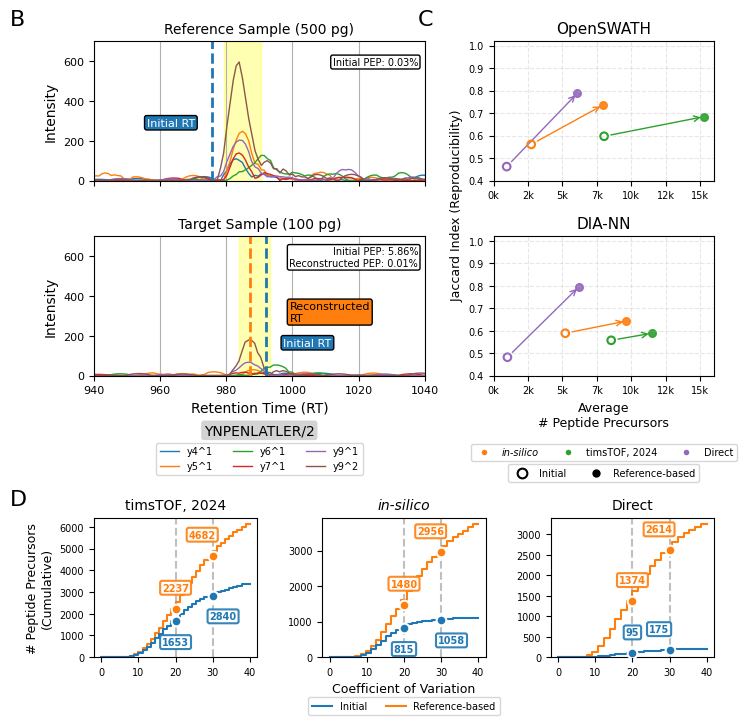

In [16]:
# We keep the 7x7 figure size
fig = plt.figure(figsize=(8, 8))

# Create main GridSpec: 2 rows, 1 column.
gs = gridspec.GridSpec(2, 1, height_ratios=[12, 5], hspace=0.6)

# --- Top Section: 2x2 grid with asymmetric widths ---
gs_top = gridspec.GridSpecFromSubplotSpec(
    2, 2, 
    subplot_spec=gs[0, 0], 
    hspace=0.4, 
    wspace=0.25,
    width_ratios=[3, 2] 
)

# Big plots
ax_big1 = fig.add_subplot(gs_top[0, 0])
ax_big2 = fig.add_subplot(gs_top[1, 0])
ax_big3 = fig.add_subplot(gs_top[0, 1])
ax_big4 = fig.add_subplot(gs_top[1, 1])


createChromatograms(ax_big1, ax_big2)
createID_Reproducibility_plot(osw_df, title='OpenSWATH', ax=ax_big3, show_xlabel=False, show_ylabel=False, show_legends=False)
createID_Reproducibility_plot(diann_df, title='DIA-NN', ax=ax_big4, show_xlabel=True)

# --- Bottom Section: 1x5 grid for square Small plots ---
gs_bottom = gridspec.GridSpecFromSubplotSpec(
    1, 3, 
    subplot_spec=gs[1, 0], 
    wspace=0.4
)

# Quantification ID Curves
for i, lib in enumerate(names.values()):
    ax = fig.add_subplot(gs_bottom[0, i])
    kwargs = dict()
    if i==0:
        kwargs = dict(ylabel=True)
    elif i==1:
        kwargs = dict(xlabel=True, legend=True)
    if lib == 'Direct':
        plot_cumulative_cv(ax, cvs_df, lib, label_offset = {condition['orig']:15, condition['refined']:15}, **kwargs)
    else:
        plot_cumulative_cv(ax, cvs_df, lib, **kwargs)

fig.text(0.02, 0.9, 'B', fontsize=16) 
fig.text(0.53, 0.9, 'C', fontsize=16) 
fig.text(0.02, 0.3, 'D', fontsize=16) 
    
plt.savefig("figure5.svg")

---

#### **Numbers For Publication**

In [17]:
osw_df

,Condition,Library,# IDs,Jaccard Index
0,Initial,"timsTOF, 2024",8024.111111,0.596834
1,Reference-based,"timsTOF, 2024",15242.555556,0.683748
2,Initial,Direct,952.875000,0.461826
3,Reference-based,Direct,6089.888889,0.788842
4,Initial,in-silico,2735.777778,0.560666
5,Reference-based,in-silico,7944.111111,0.735927


In [18]:
diann_df

,Condition,Library,# IDs,Jaccard Index
0,Initial,"timsTOF, 2024",8538.666667,0.557119
1,Reference-based,"timsTOF, 2024",11463.888889,0.588270
2,Initial,in-silico,5207.555556,0.588684
3,Reference-based,in-silico,9609.888889,0.642480
4,Initial,Direct,1006.375000,0.481947
5,Reference-based,Direct,6198.000000,0.795228


In [19]:
6089.888889 / 952.875000

6.391067966942148

In [20]:
6198.000000 / 1006.375000

6.158738044963359

In [21]:
percent_increase(8024.111111, 15242.555556)

89.95942784372043

In [22]:
percent_increase(8538.666667, 11463.888889)

34.258536327519586

In [23]:
percent_increase(5207.555556, 9609.888889)

84.53742424173956

In [24]:
percent_increase(2735.777778, 7944.111111)

190.37852324422238

#### **Effect Size Quantification**

Hannes also wants me to quantify the effect size on the quantification curves

In [25]:
def get_quant_rslts(cvs, software):
    quant_rslts = { i:defaultdict(dict) for i in cvs.keys() }
    for lib in cvs.keys():
        for cond in cvs[lib].keys():
            tmp = cvs[lib][cond]
            for cutoff in [20, 30]:
                quant_rslts[lib][cond][cutoff] = len(tmp[tmp['cv'] < cutoff])
        
    
    rows = []
    
    for lib, conditions in quant_rslts.items():
        for cond, depths in conditions.items():
            for depth, value in depths.items():
                rows.append((lib, cond, depth, value))
    
    quant_rslts = pd.DataFrame(rows, columns=["library", "condition", "cv", "ids"])
    quant_rslts['software'] = software
    return quant_rslts

quant_rslts_osw = get_quant_rslts(cvs, 'OpenSWATH')


In [26]:
quant_rslts_summary = quant_rslts_osw[['condition', 'cv','ids']].groupby(['cv', 'condition']).mean()
quant_rslts_summary

ids
cv condition                   
20 Initial           854.333333
   Reference-based  1697.000000
30 Initial          1357.666667
   Reference-based  3417.333333

In [27]:
quant_rslts_summary.loc[(20, 'Reference-based'), 'ids'] - quant_rslts_summary.loc[(20, 'Initial'), 'ids']

np.float64(842.6666666666666)

In [28]:
quant_rslts_summary.loc[(30, 'Reference-based'), 'ids'] - quant_rslts_summary.loc[(30, 'Initial'), 'ids']

np.float64(2059.666666666667)